In [1]:
%pip install pandas numpy seaborn matplotlib scikit-learn jupyter imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier
import joblib, os 
os.environ['LOKY_MAX_CPU_COUNT'] = '10'


In [ ]:
df_orig = pd.read_csv('data/raw/housing.csv')

In [4]:
df_orig.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
features = ['Latitude', 'Longitude', 'MedInc']

In [6]:
df= df_orig[features]

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [8]:
df.describe()

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


In [9]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [10]:
df_train = df_train.copy()
df_test  = df_test.copy()

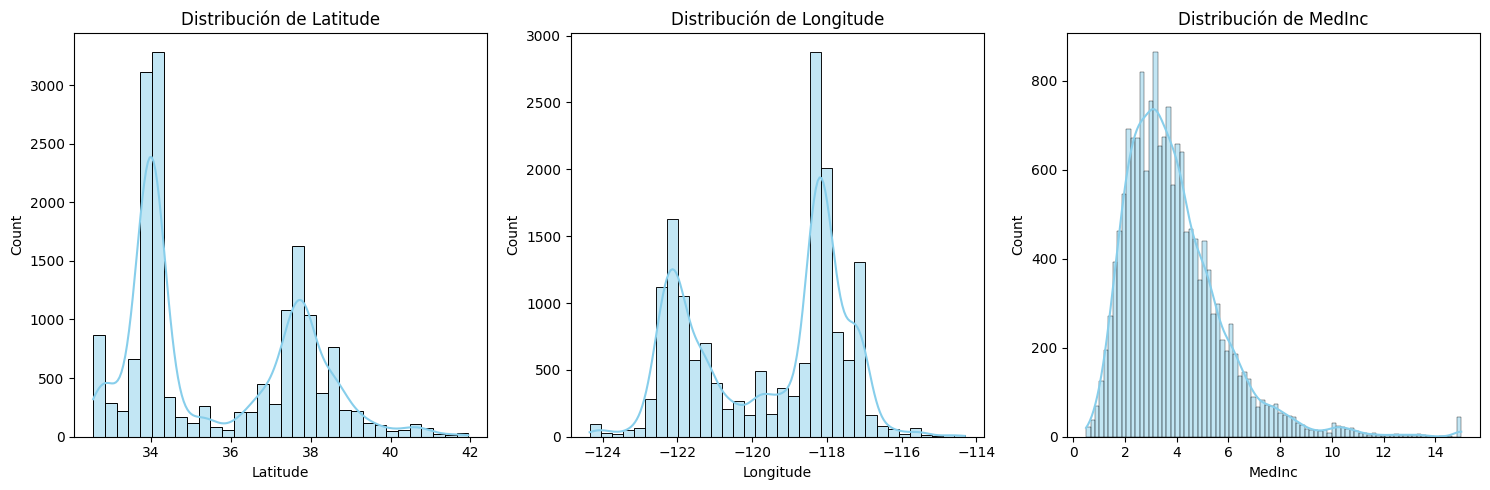

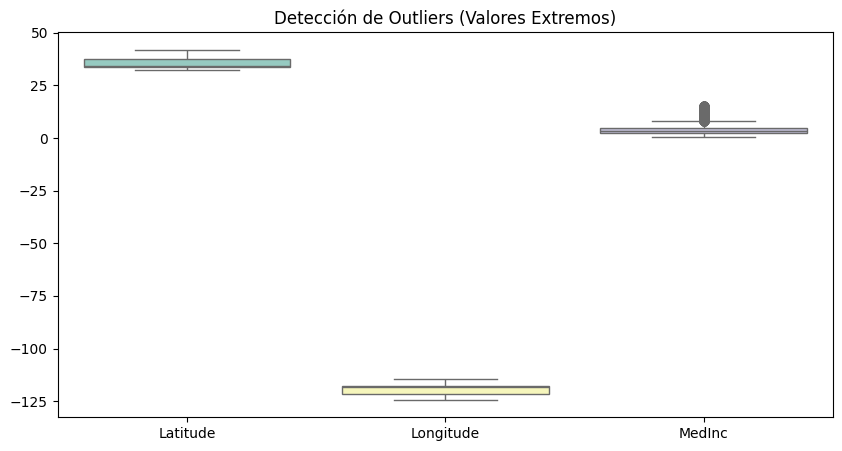

In [ ]:

# Visualizar histogramas para ver la forma 
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_train[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# Visualizar Boxplots para detectar Outliers 
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_train[features], palette='Set3')
plt.title('Detección de Outliers (Valores Extremos)')
plt.show()

Seleccion del mejor escalador: La diferencia entre los datos observados en los histogramas donde se ven dos tipos de distribución un binomial y una muy parecida a una distribucion gausiana con cola hacia la derecha. Debiso e este tipo de comportamiento evaluare cual seria el mejor escalador para estos datos entr Standard, MinMax, Robust. 

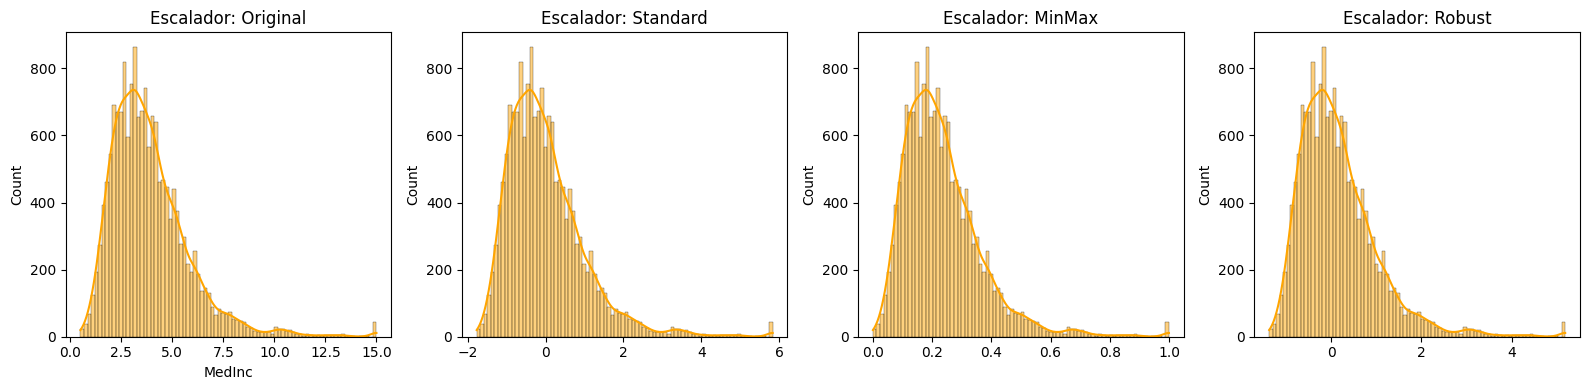

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Creamos un diccionario para iterar y comparar
scalers = {
    'Original': None,
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

# Configuración de la gráfica para comparar solo 'MedInc' 
plt.figure(figsize=(16, 4))

for i, (name, scaler) in enumerate(scalers.items()):
    plt.subplot(1, 4, i+1)
    
    if name == 'Original':
        data_plot = df_train['MedInc']
    else:
        
        data_scaled = scaler.fit_transform(df_train[['MedInc']])
        data_plot = data_scaled.flatten()
        
    sns.histplot(data_plot, kde=True, color='orange')
    plt.title(f'Escalador: {name}')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Calculamos el máximo para cada método
max_std = StandardScaler().fit_transform(df_train[['MedInc']]).max()
max_rob = RobustScaler().fit_transform(df_train[['MedInc']]).max()

print(f"Puntaje del valor maximo (15.0) con Standard: {max_std:.2f}")
print(f"Puntaje del valor maximo (15.0) con Robust:   {max_rob:.2f}")

Puntaje del valor maximo (15.0) con Standard: 5.84
Puntaje del valor maximo (15.0) con Robust:   5.19


In [14]:
X_train=df_train[features] 
X_test=df_test[features]

In [ ]:
from sklearn.preprocessing import RobustScaler 



#Escalar 
rob_scaler = RobustScaler()
X_train_scaled = rob_scaler.fit_transform(X_train)
X_test_scaled = rob_scaler.transform(X_test)

# Entrenar K-Means con los datos ESCALADOS
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
km6.fit(X_train_scaled)

df_train['Cluster'] = km6.labels_
df_test['Cluster'] = km6.predict(X_test_scaled)

# Ver los centroides en valores reales
centroides_reales = rob_scaler.inverse_transform(km6.cluster_centers_)
df_centroides = pd.DataFrame(centroides_reales, columns=features)

print("--- Centroides en valores reales (Dólares y Coordenadas) ---")
print(df_centroides)

--- Centroides en valores reales (Dólares y Coordenadas) ---
    Latitude   Longitude     MedInc
0  38.139024 -121.636482   2.719707
1  33.916824 -118.015523   4.194956
2  35.647347 -120.019682  10.910409
3  34.039945 -118.019015   2.377351
4  33.876490 -118.061878   6.500243
5  37.727892 -121.907167   5.282966


In [16]:
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
km6.fit(X_train_scaled)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [17]:
df_train = df_train.copy() 
df_test = df_test.copy()

In [18]:
km6.labels_

array([1, 1, 1, ..., 3, 5, 0])

In [19]:
df_train['Cluster'] = km6.labels_

In [20]:
df_train.head()

,Latitude,Longitude,MedInc,Cluster
14196,32.71,-117.03,3.2596,1
8267,33.77,-118.16,3.8125,1
17445,34.66,-120.48,4.1563,1
14265,32.69,-117.11,1.9425,3
2271,36.78,-119.80,3.5542,0


In [21]:
df_train.columns

Index(['Latitude', 'Longitude', 'MedInc', 'Cluster'], dtype='str')

In [22]:
df_train['Cluster'].value_counts().sort_index()

Cluster
0    4267
1    3735
2     378
3    4159
4    1512
5    2461
Name: count, dtype: int64

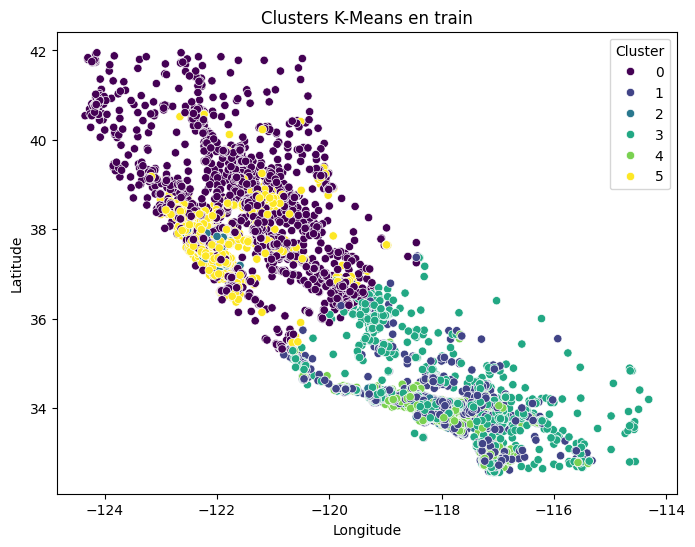

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis'
)
plt.title('Clusters K-Means en train')
plt.show()

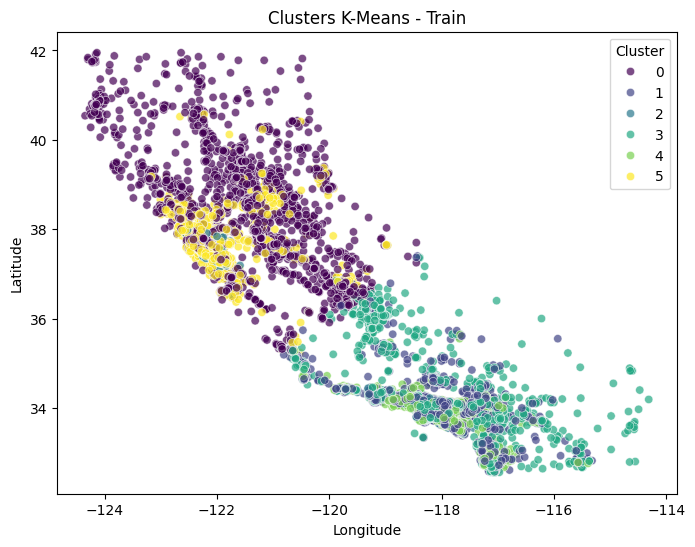

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Clusters K-Means - Train')
plt.show()

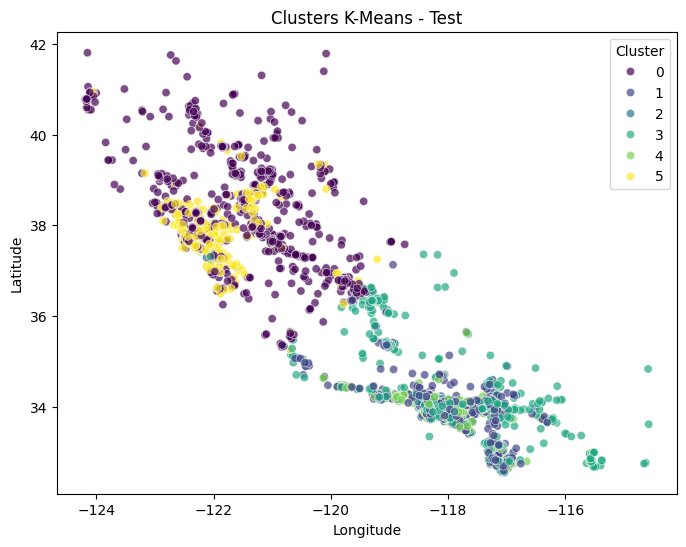

In [25]:
df_test['Cluster'] = km6.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_test,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Clusters K-Means - Test')
plt.show()

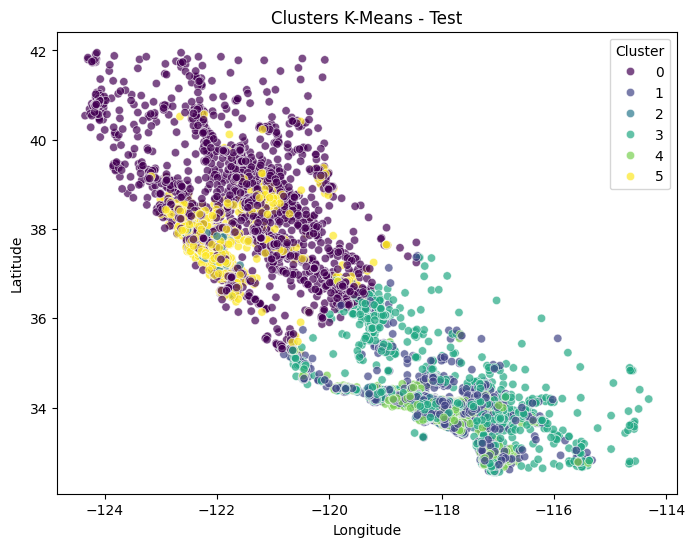

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pd.concat([df_test, df_train]),
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Clusters K-Means - Test')
plt.show()

In [27]:


print(features)

['Latitude', 'Longitude', 'MedInc']


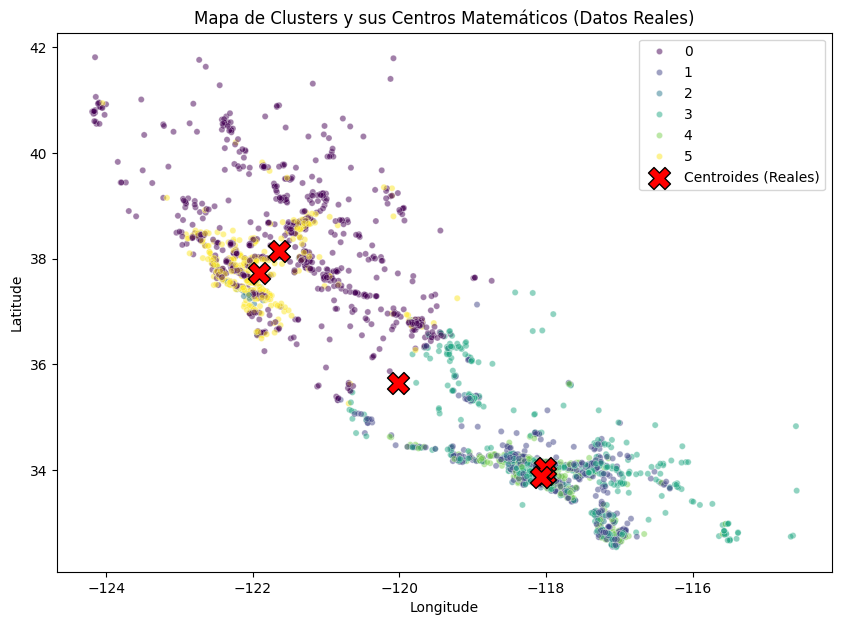

In [ ]:
# Traducir los centroides de "escala robusta" a "escala real"

centroides_reales = rob_scaler.inverse_transform(km6.cluster_centers_)

# Crear la figura
plt.figure(figsize=(10, 7))

# Dibujar los puntos de las casas 
sns.scatterplot(
    data=df_test,
    x='Longitude',
    y='Latitude',
    hue='Cluster', 
    palette='viridis',
    alpha=0.5,
    s=20
)

# Dibujar los centroides traducidos encima
# centroides_reales[:, 1] es Longitud (X)
# centroides_reales[:, 0] es Latitud (Y)
plt.scatter(
    centroides_reales[:, 1], 
    centroides_reales[:, 0], 
    marker='X', 
    color='red',   
    label='Centroides (Reales)',
    edgecolor='black'
)

plt.title('Mapa de Clusters y sus Centros Matemáticos (Datos Reales)')
plt.legend()
plt.show()

In [29]:
# Creamos un DataFrame con los centros de los clusters
centroides_escalados = pd.DataFrame(
    km6.cluster_centers_, 
    columns=features
)

print(centroides_escalados)

   Latitude  Longitude    MedInc
0  1.023489  -0.822758 -0.374395
1 -0.090548   0.130125  0.294205
2  0.366055  -0.397285  3.337726
3 -0.058062   0.129207 -0.529555
4 -0.101190   0.117927  1.338988
5  0.915011  -0.893991  0.787304


In [30]:
# Agrupamos por clúster y calculamos la media de cada variable
resumen_clusters = df_test.groupby('Cluster')[['Latitude', 'Longitude', 'MedInc']].mean()

# Añadimos el conteo de casas por clúster
resumen_clusters['Cantidad'] = df_test.groupby('Cluster').size()

print(resumen_clusters)

          Latitude   Longitude     MedInc  Cantidad
Cluster                                            
0        38.107774 -121.590092   2.710969      1087
1        33.890439 -118.014433   4.165692       979
2        35.085889 -119.449333  11.035343        90
3        34.031085 -117.980632   2.389045      1060
4        33.843179 -118.025983   6.485570       346
5        37.737862 -121.951343   5.330430       566


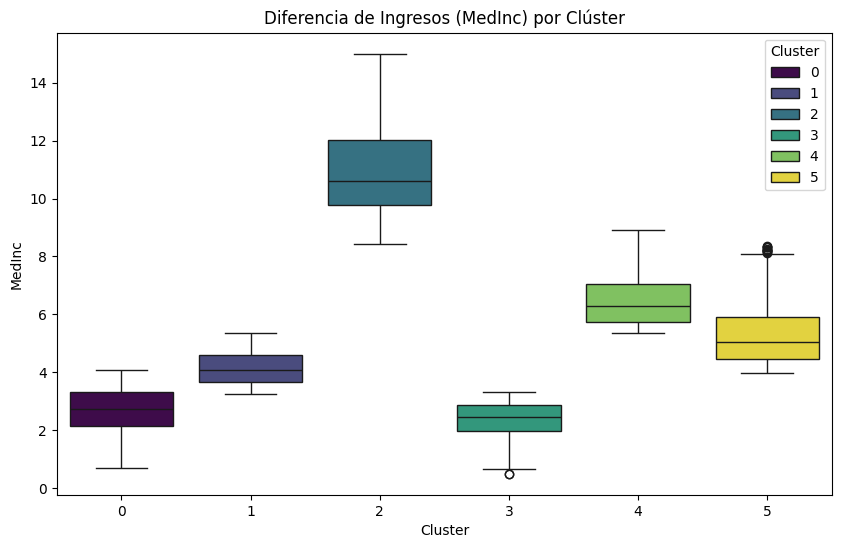

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='MedInc', data=df_test, hue='Cluster', palette='viridis')
plt.title('Diferencia de Ingresos (MedInc) por Clúster')
plt.show();

In [ ]:
from sklearn.metrics import silhouette_score

# Definimos los dos modelos a comparar
modelos = {
    'K=3': KMeans(n_clusters=3, random_state=42, n_init=10),
    'K=5': KMeans(n_clusters=5, random_state=42, n_init=10),
    'K=6': KMeans(n_clusters=6, random_state=42, n_init=10)
}

print("--- Comparativa de Calidad (Silhouette Score) ---")
for nombre, modelo in modelos.items():
    # Entrenamos y obtenemos etiquetas
    labels = modelo.fit_predict(X_train_scaled)
    
    # Calculamos la silueta solo con una muestra 
    score = silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=42)
    print(f"Puntaje de Silueta para {nombre}: {score:.4f}")

--- Comparativa de Calidad (Silhouette Score) ---
Puntaje de Silueta para K=3: 0.4684
Puntaje de Silueta para K=5: 0.4396
Puntaje de Silueta para K=6: 0.4067


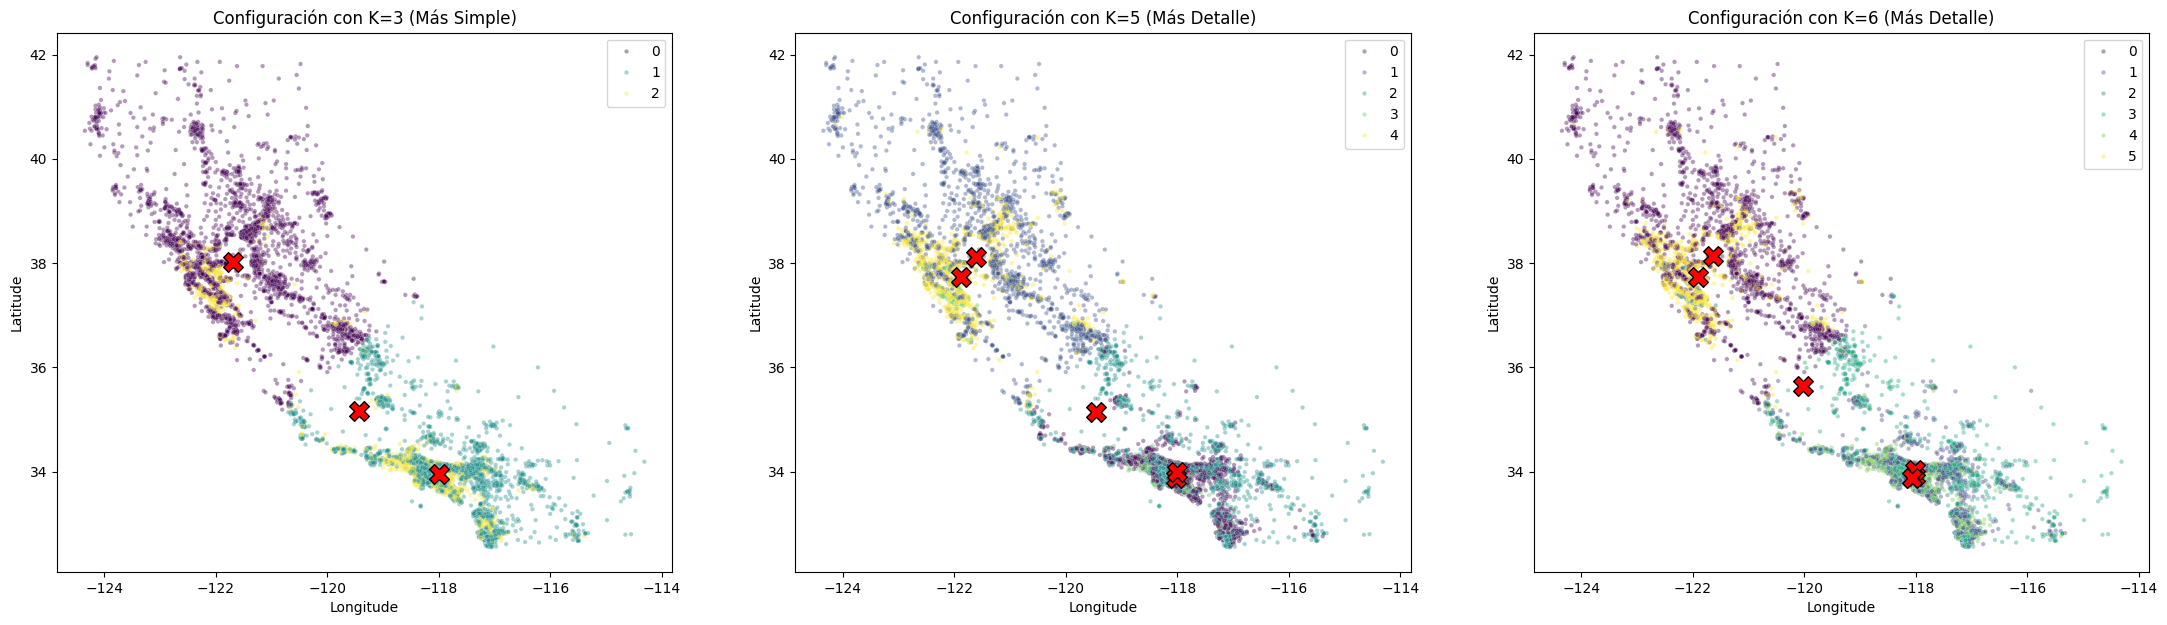

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(27, 7))

# --- MAPA PARA K=3 ---
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_train_scaled)
labels3 = km3.predict(X_train_scaled)
cent3 = rob_scaler.inverse_transform(km3.cluster_centers_)

sns.scatterplot(x=df_train['Longitude'], y=df_train['Latitude'], hue=labels3, 
                palette='viridis', alpha=0.4, ax=ax1, s=10)
ax1.scatter(cent3[:, 1], cent3[:, 0], marker='X', s=200, color='red', edgecolor='black')
ax1.set_title('Configuración con K=3 (Más Simple)')

# --- MAPA PARA K=5 ---
km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_train_scaled)
labels5 = km5.predict(X_train_scaled)
cent5 = rob_scaler.inverse_transform(km5.cluster_centers_)

sns.scatterplot(x=df_train['Longitude'], y=df_train['Latitude'], hue=labels5, 
                palette='viridis', alpha=0.4, ax=ax2, s=10)
ax2.scatter(cent5[:, 1], cent5[:, 0], marker='X', s=200, color='red', edgecolor='black')
ax2.set_title('Configuración con K=5 (Más Detalle)')

# --- MAPA PARA K=6 ---
km6 = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_train_scaled)
labels6 = km6.predict(X_train_scaled)
cent6 = rob_scaler.inverse_transform(km6.cluster_centers_)

sns.scatterplot(x=df_train['Longitude'], y=df_train['Latitude'], hue=labels6, 
                palette='viridis', alpha=0.4, ax=ax3, s=10)
ax3.scatter(cent6[:, 1], cent6[:, 0], marker='X', s=200, color='red', edgecolor='black')
ax3.set_title('Configuración con K=6 (Más Detalle)')

plt.show()

In [ ]:


# Preparar los datos (X = variables, y = etiqueta del cluster)
X_train = df_train[features]
y_train = df_train['Cluster']
X_test = df_test[features]
y_test = df_test['Cluster']

# Entrenar el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Realizar predicciones
y_pred = rf_model.predict(X_test)

# Obtener estadísticas
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión Global (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión Global (Accuracy): 0.9942

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1087
           1       1.00      0.99      0.99       979
           2       0.99      0.98      0.98        90
           3       0.99      1.00      0.99      1060
           4       0.99      1.00      1.00       346
           5       0.99      0.99      0.99       566

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



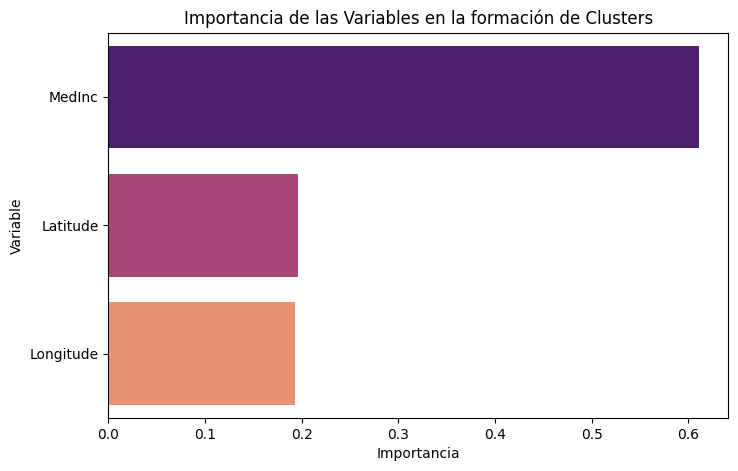

In [35]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Variable': features, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Variable', data=feature_imp_df, hue='Variable', palette='magma')
plt.title('Importancia de las Variables en la formación de Clusters')
plt.show()

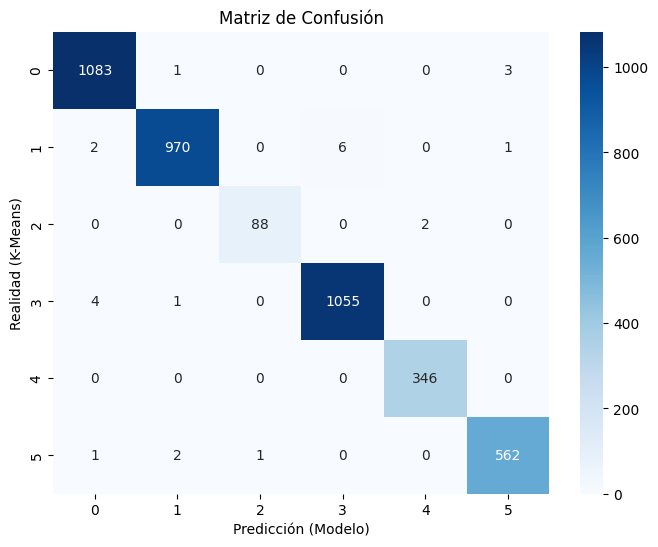

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (K-Means)')
plt.title('Matriz de Confusión')
plt.show()

In [37]:
os.makedirs('modelos', exist_ok=True)
joblib.dump(km6,        'modelos/km6_model.pkl')
joblib.dump(rob_scaler, 'modelos/rob_scaler.pkl')
joblib.dump(rf_model,   'modelos/rf_model.pkl')
print("Modelos guardados correctamente.")

Modelos guardados correctamente.


#### Conclusiones

1.- Optimización del Escalado de Datos: Realicé una comparativa entre distintos métodos de normalización para determinar cuál se ajustaba mejor a la naturaleza del dataset. Dado que la distribución de variables como MedInc presenta una asimetría hacia la derecha y valores atípicos, el uso de RobustScaler resultó ser la aproximación más técnica y precisa. A diferencia de otros escaladores, este permitió que el modelo de clustering se centrara en la estructura real de los datos sin verse sesgado por los valores extremos.

2.- Determinación del Número de Clusters ($k$): Mediante la revisión del método del codo y el análisis de la inercia, evalué las variaciones en la segmentación según el número de grupos. Si bien a nivel de cálculo la inercia disminuye de forma gradual, la descripción cualitativa que el modelo hace de los clusters sugiere que entre 5 y 6 grupos se obtiene la mejor definición. Esta configuración ofrece el equilibrio óptimo para la estrategia del problema, permitiendo diferenciar con claridad las distintas zonas socioeconómicas.

3.- Validación con Random Forest: La integración de un modelo de Random Forest sirvió como métrica de validación para el aprendizaje no supervisado. El hecho de que el modelo fuera capaz de identificar y predecir las etiquetas de los clusters con una precisión tan alta confirma que la segmentación realizada por K-Means es sólida, consistente y que las fronteras entre cada grupo están claramente definidas por las variables de entrada

4.- Análisis de la Silueta y Cohesión de Grupos: Complementé la validación del modelo mediante el coeficiente de silueta, evaluando la relación entre la cohesión interna de los clusters y su separación. Los resultados obtenidos para la configuración de $k=6$ mostraron un balance superior en comparación con valores menores de $k$; esto confirma que la distancia entre los puntos de un mismo grupo es mínima en comparación con la distancia al cluster vecino más cercano. El uso de esta métrica me permitió cuantificar la calidad del agrupamiento, garantizando que la segmentación socio-geográfica obtenida es matemáticamente robusta y representativa de la realidad del dat

